In [1]:
from pyspark.sql import SparkSession

In [2]:

spark = SparkSession.builder \
    .appName("YelpDataAnalysis") \
    .getOrCreate()

24/11/19 19:20:16 WARN Utils: Your hostname, yelp resolves to a loopback address: 127.0.1.1; using 192.168.64.2 instead (on interface enp0s1)
24/11/19 19:20:16 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/11/19 19:20:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
yelp_df = spark.read.json("file:///home/dps/Documents/yelp_dataset/yelp_academic_dataset_business.json")

24/11/19 19:20:25 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [4]:
yelp_df.printSchema()
yelp_df.show(5)

root
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: string (nullable = true)
 |    |-- Caters: string (nullable = true)
 |    |-- CoatCheck: string (nullable = true)
 |    |-- Corkage: string (nullable = true)
 |    |-- DietaryRestrictions: string (nullable = true)
 |    |-- DogsAllowed: string (nullable = true)
 |    |-- DriveThru: string (nullable = true)
 |    |-- GoodForDancing: str

In [5]:
arizona_df = yelp_df.filter(yelp_df["state"] == "AZ")

# Show first few rows
arizona_df.show(5)

+--------------------+--------------------+--------------------+--------------------+------+--------------------+-------+----------+------------+--------------------+-----------+------------+-----+-----+
|             address|          attributes|         business_id|          categories|  city|               hours|is_open|  latitude|   longitude|                name|postal_code|review_count|stars|state|
+--------------------+--------------------+--------------------+--------------------+------+--------------------+-------+----------+------------+--------------------+-----------+------------+-----+-----+
|5255 E Broadway Blvd|{null, null, null...|tUFrWirKiKi_TAnsV...|Department Stores...|Tucson|{8:0-23:0, 8:0-22...|      0| 32.223236| -110.880452|              Target|      85711|          22|  3.5|   AZ|
|     625 N Stone Ave|{null, null, null...|rBmpy_Y1UbBx8ggHl...|Automotive, Auto ...|Tucson|{8:0-17:0, 0:0-0:...|      1|32.2298719|-110.9723419|Arizona Truck Out...|      85705|      

In [6]:
arizona_df.write.mode("overwrite").parquet("file:///home/dps/Documents/temp/arizona_businesses.parquet")

In [7]:
yelp_df.select("categories").distinct().show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------+
|categories                                                                                                                   |
+-----------------------------------------------------------------------------------------------------------------------------+
|Arts & Entertainment, Event Planning & Services, Venues & Event Spaces, Museums                                              |
|Food, Convenience Stores, Restaurants, Food Delivery Services, Local Flavor, Delis                                           |
|Automotive, Auto Repair, Towing, Body Shops, Oil Change Stations, Auto Parts & Supplies, Tires                               |
|Makeup Artists, Hair Salons, Beauty & Spas                                                                                   |
|Breweries, American (New), Restaurants, Burgers, American (Traditional), Gastropubs, Brewpubs, Food, Fi

In [8]:
az_df = spark.read.parquet("file:///home/dps/Documents/temp/arizona_businesses.parquet")
az_df.createOrReplaceTempView("arizona_businesses")

In [9]:
restaurants_df = az_df.filter(az_df["categories"].contains("Restaurants"))
restaurants_df.show(5)
restaurants_df.createOrReplaceTempView("restaurants")

+--------------------+--------------------+--------------------+--------------------+------+--------------------+-------+-------------+---------------+--------------------+-----------+------------+-----+-----+
|             address|          attributes|         business_id|          categories|  city|               hours|is_open|     latitude|      longitude|                name|postal_code|review_count|stars|state|
+--------------------+--------------------+--------------------+--------------------+------+--------------------+-------+-------------+---------------+--------------------+-----------+------------+-----+-----+
|8581 N Silverbell Rd|{null, null, u'no...|2tAi411srrpmMofeA...|Coffee & Tea, Bre...|Tucson|{6:30-12:0, 0:0-0...|      1|    32.362689|    -111.120753|Just Breakfast on...|      85743|         113|  3.5|   AZ|
|   245 E Congress St|{null, null, null...|JkQz12i_Eubd_xQdL...|Restaurants, Food...|Tucson|{12:0-22:0, 12:0-...|      1|   32.2221884|   -110.9673208|HUB Ice C

In [10]:
attributes_schema = restaurants_df.schema["attributes"].dataType
print(attributes_schema)
print()
attribute_list_all = attributes_schema.fieldNames()
print(attribute_list_all)

from pyspark.sql.functions import col, when

for attr in attribute_list_all:
    restaurants_df = restaurants_df.withColumn(attr, col("attributes").getItem(attr))

for attr in attribute_list_all:
    restaurants_df = restaurants_df.withColumn(attr, when(col(attr).isNull(), "Unknown").otherwise(col(attr)))

for attr in attribute_list_all:
    print(f"\nValue counts for '{attr}':")
    total_count = restaurants_df.filter(col(attr).isNotNull()).count()
    print(total_count)
    restaurants_df.groupBy(attr).count().orderBy("count", ascending=False).show()


StructType([StructField('AcceptsInsurance', StringType(), True), StructField('AgesAllowed', StringType(), True), StructField('Alcohol', StringType(), True), StructField('Ambience', StringType(), True), StructField('BYOB', StringType(), True), StructField('BYOBCorkage', StringType(), True), StructField('BestNights', StringType(), True), StructField('BikeParking', StringType(), True), StructField('BusinessAcceptsBitcoin', StringType(), True), StructField('BusinessAcceptsCreditCards', StringType(), True), StructField('BusinessParking', StringType(), True), StructField('ByAppointmentOnly', StringType(), True), StructField('Caters', StringType(), True), StructField('CoatCheck', StringType(), True), StructField('Corkage', StringType(), True), StructField('DietaryRestrictions', StringType(), True), StructField('DogsAllowed', StringType(), True), StructField('DriveThru', StringType(), True), StructField('GoodForDancing', StringType(), True), StructField('GoodForKids', StringType(), True), Stru

DATA PROCESSING

In [11]:
from pyspark.sql.functions import from_json, when
from pyspark.sql.types import MapType, StringType

attribute_list = ["Alcohol", "Ambience", "BusinessParking", "GoodForKids", "GoodForMeal", "HasTV", "NoiseLevel", "OutdoorSeating", "RestaurantsGoodForGroups", "RestaurantsPriceRange2", "WiFi"]

for attr in attribute_list:
    restaurants_df = restaurants_df.withColumn(attr, col(f"attributes.{attr}"))

from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType
import re

def clean_json_string(s):
    if s is None or s in ('Unknown', 'None'):
        return None
    s = s.replace("'", '"')
    s = re.sub(r'u"', '"', s)
    s = s.replace('True', 'true').replace('False', 'false')
    s = s.replace('None', 'null')
    return s

clean_json_udf = udf(clean_json_string, StringType())

restaurants_df = restaurants_df.withColumn('Ambience_clean', clean_json_udf(col('Ambience')))
restaurants_df = restaurants_df.withColumn('BusinessParking_clean', clean_json_udf(col('BusinessParking')))
restaurants_df = restaurants_df.withColumn('GoodForMeal_clean', clean_json_udf(col('GoodForMeal')))

from pyspark.sql.functions import from_json
from pyspark.sql.types import MapType, StringType

json_schema = MapType(StringType(), StringType())

restaurants_df = restaurants_df.withColumn('Ambience_parsed', from_json(col('Ambience_clean'), json_schema))
restaurants_df = restaurants_df.withColumn('BusinessParking_parsed', from_json(col('BusinessParking_clean'), json_schema))
restaurants_df = restaurants_df.withColumn('GoodForMeal_parsed', from_json(col('GoodForMeal_clean'), json_schema))

ambience_attrs = ["romantic", "intimate", "classy", "hipster", "divey",
                  "touristy", "trendy", "upscale", "casual"]

for sub_attr in ambience_attrs:
    restaurants_df = restaurants_df.withColumn(
        f"Ambience_{sub_attr.capitalize()}",
        col(f"Ambience_parsed.`{sub_attr}`")
    )

parking_attrs = ["garage", "street", "validated", "lot", "valet"]

for sub_attr in parking_attrs:
    restaurants_df = restaurants_df.withColumn(
        f"Parking_{sub_attr.capitalize()}",
        col(f"BusinessParking_parsed.`{sub_attr}`")
    )
goodformeal_attrs = ["dessert", "latenight", "lunch", "dinner", "brunch", "breakfast"]

for sub_attr in goodformeal_attrs:
    restaurants_df = restaurants_df.withColumn(
        f"GoodForMeal_{sub_attr.capitalize()}",
        col(f"GoodForMeal_parsed.`{sub_attr}`")
    )

boolean_attrs = ["GoodForKids", "HasTV", "OutdoorSeating", "RestaurantsGoodForGroups"] + \
                [f"Ambience_{sub_attr.capitalize()}" for sub_attr in ambience_attrs] + \
                [f"Parking_{sub_attr.capitalize()}" for sub_attr in parking_attrs] + \
                [f"GoodForMeal_{sub_attr.capitalize()}" for sub_attr in goodformeal_attrs]

for attr in boolean_attrs:
    restaurants_df = restaurants_df.withColumn(attr, when(col(attr) == 'true', True)
                                                        .when(col(attr) == 'false', False)
                                                        .otherwise(None))

restaurants_df = restaurants_df.withColumn("PriceRange", col("RestaurantsPriceRange2").cast("integer"))

from pyspark.sql.functions import regexp_replace, col

attributes_to_clean = ["Alcohol", "NoiseLevel", "WiFi"]

for attr in attributes_to_clean:
    restaurants_df = restaurants_df.withColumn(attr, regexp_replace(col(attr), r"^u?'(.*)'$", "$1"))

restaurants_df = restaurants_df.withColumn("WiFi", when(col("WiFi").isin('free', 'paid', 'no'), col("WiFi"))
                                                     .otherwise('unknown'))

restaurants_df = restaurants_df.withColumn("NoiseLevel", when(col("NoiseLevel").isin('quiet', 'average', 'loud', 'very_loud'), col("NoiseLevel"))
                                                           .otherwise('unknown'))

restaurants_df.select("name", "Alcohol", "PriceRange", "WiFi", "NoiseLevel", "GoodForKids", "OutdoorSeating", "HasTV").show(20, truncate=False)

restaurants_df.createOrReplaceTempView("restaurants")

+----------------------------+-------------+----------+-------+----------+-----------+--------------+-----+
|name                        |Alcohol      |PriceRange|WiFi   |NoiseLevel|GoodForKids|OutdoorSeating|HasTV|
+----------------------------+-------------+----------+-------+----------+-----------+--------------+-----+
|Just Breakfast on Silverbell|none         |1         |free   |average   |null       |null          |null |
|HUB Ice Cream Factory       |null         |1         |no     |average   |null       |null          |null |
|Rocco's Little Chicago      |beer_and_wine|2         |no     |average   |null       |null          |null |
|Sunny Side Up Cafe          |none         |1         |no     |average   |null       |null          |null |
|Papa John's Pizza           |none         |1         |no     |average   |null       |null          |null |
|Taco Bell                   |none         |1         |no     |average   |null       |null          |null |
|Monterey Court             

QUERIES AND VISUALIZATION

In [12]:
from pyspark.sql.functions import col, when, avg, count, explode, array, round as pyspark_round
from pyspark.sql.types import IntegerType, FloatType
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [13]:
# Query 1 - Simple: Distribution of Restaurants by City and Their Average Ratings

city_distribution_df = spark.sql("""
SELECT
    city,
    COUNT(*) AS total_restaurants,
    ROUND(AVG(stars), 2) AS avg_rating
FROM
    restaurants
GROUP BY
    city
ORDER BY
    total_restaurants DESC
LIMIT 10
""")
city_distribution_df.show()

+------------+-----------------+----------+
|        city|total_restaurants|avg_rating|
+------------+-----------------+----------+
|      Tucson|             2466|      3.46|
|  Oro Valley|               80|      3.48|
|      Marana|               39|      3.28|
|Green Valley|               26|      3.17|
|   Sahuarita|               17|      3.06|
|        Vail|               16|      3.34|
|    Catalina|                7|      3.43|
|      Tuscon|                5|       3.4|
|Mount Lemmon|                4|      3.13|
|South Tucson|                2|      2.25|
+------------+-----------------+----------+



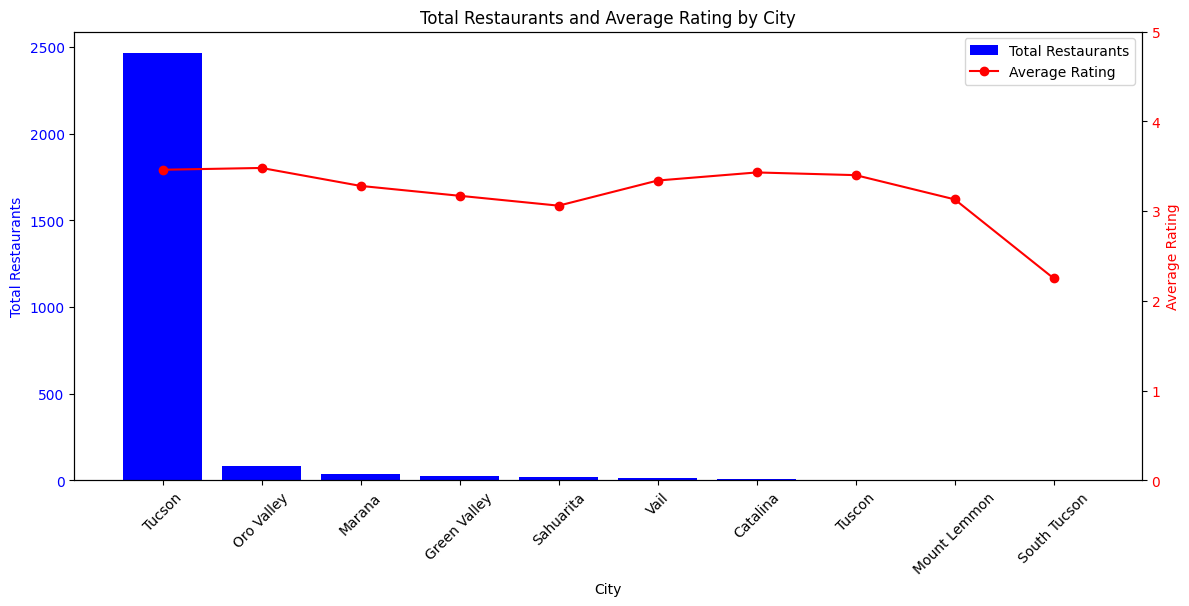

In [14]:
city_distribution_pd = city_distribution_df.toPandas()

city_distribution_pd = city_distribution_pd.sort_values('total_restaurants', ascending=False)

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

cities = city_distribution_pd['city']
x = range(len(cities))

ax1.bar(x, city_distribution_pd['total_restaurants'], color='blue', label='Total Restaurants')
ax1.set_xlabel('City')
ax1.set_ylabel('Total Restaurants', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(cities, rotation=45)

# Create a second y-axis for avg_rating
ax2 = ax1.twinx()
ax2.plot(x, city_distribution_pd['avg_rating'], color='red', marker='o', label='Average Rating')
ax2.set_ylabel('Average Rating', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 5)

# Add legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

fig.tight_layout()
plt.title('Total Restaurants and Average Rating by City')
plt.show()

In [15]:
# Query 2 - Simple: Effect of Alcohol Availability and Price Range on Ratings

alcohol_price_df = spark.sql("""
SELECT
    Alcohol,
    PriceRange,
    ROUND(AVG(stars), 2) AS avg_rating,
    COUNT(*) AS total_restaurants
FROM
    restaurants
WHERE
    PriceRange IS NOT NULL
GROUP BY
    Alcohol, PriceRange
ORDER BY
    avg_rating DESC
""")
alcohol_price_df.show()

+-------------+----------+----------+-----------------+
|      Alcohol|PriceRange|avg_rating|total_restaurants|
+-------------+----------+----------+-----------------+
|     full_bar|         3|      3.68|               42|
|         none|         2|      3.67|              174|
|beer_and_wine|         2|      3.67|              197|
|         null|         2|      3.61|              100|
|beer_and_wine|         1|      3.51|              117|
|beer_and_wine|         3|       3.5|                2|
|     full_bar|         2|      3.47|              583|
|     full_bar|         4|      3.39|                9|
|     full_bar|         1|      3.39|               92|
|         none|         1|      3.27|              754|
|         null|         3|      3.25|                6|
|         null|         1|      3.18|              264|
|         none|         3|      2.25|                2|
+-------------+----------+----------+-----------------+



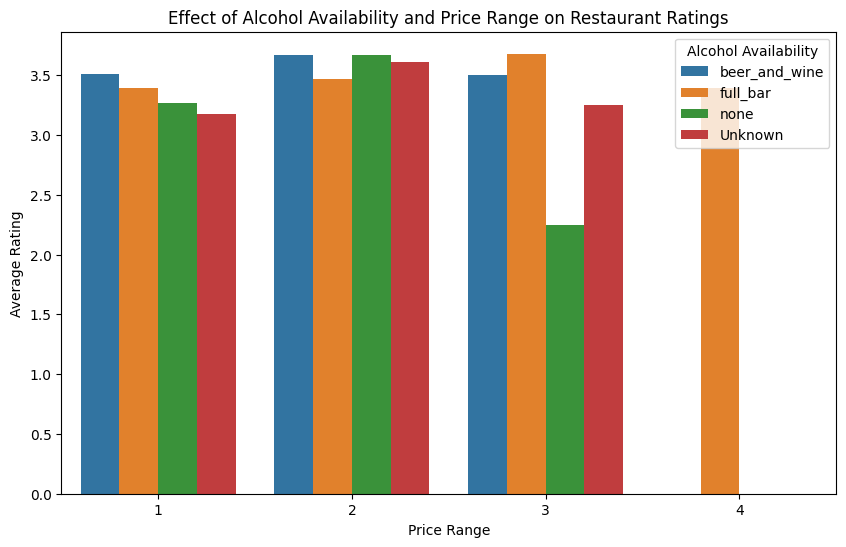

In [16]:
alcohol_price_pd = alcohol_price_df.toPandas()

alcohol_price_pd.fillna('Unknown', inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(
    data=alcohol_price_pd,
    x='PriceRange',
    y='avg_rating',
    hue='Alcohol'
)
plt.xlabel('Price Range')
plt.ylabel('Average Rating')
plt.title('Effect of Alcohol Availability and Price Range on Restaurant Ratings')
plt.legend(title='Alcohol Availability')
plt.show()

In [17]:
# Query 3 - Complex: Impact of All Considered Attributes on Restaurant Ratings

attribute_impact_df = spark.sql("""
SELECT
    Alcohol,
    Ambience_Casual,
    Ambience_Classy,
    Parking_Lot,
    GoodForKids,
    HasTV,
    NoiseLevel,
    OutdoorSeating,
    RestaurantsGoodForGroups,
    PriceRange,
    WiFi,
    ROUND(AVG(stars), 2) AS avg_rating,
    COUNT(*) AS total_restaurants
FROM
    restaurants
GROUP BY
    Alcohol,
    Ambience_Casual,
    Ambience_Classy,
    Parking_Lot,
    GoodForKids,
    HasTV,
    NoiseLevel,
    OutdoorSeating,
    RestaurantsGoodForGroups,
    PriceRange,
    WiFi
HAVING
    total_restaurants >= 5
ORDER BY
    avg_rating DESC,
    total_restaurants DESC
LIMIT 20
""")
attribute_impact_df.show(truncate=False)

+-------------+---------------+---------------+-----------+-----------+-----+----------+--------------+------------------------+----------+-------+----------+-----------------+
|Alcohol      |Ambience_Casual|Ambience_Classy|Parking_Lot|GoodForKids|HasTV|NoiseLevel|OutdoorSeating|RestaurantsGoodForGroups|PriceRange|WiFi   |avg_rating|total_restaurants|
+-------------+---------------+---------------+-----------+-----------+-----+----------+--------------+------------------------+----------+-------+----------+-----------------+
|null         |null           |null           |false      |null       |null |unknown   |null          |null                    |null      |unknown|4.39      |19               |
|none         |null           |null           |true       |null       |null |unknown   |null          |null                    |1         |no     |4.28      |9                |
|full_bar     |false          |true           |true       |null       |null |average   |null          |null        

/tmp/ipykernel_75447/529393584.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


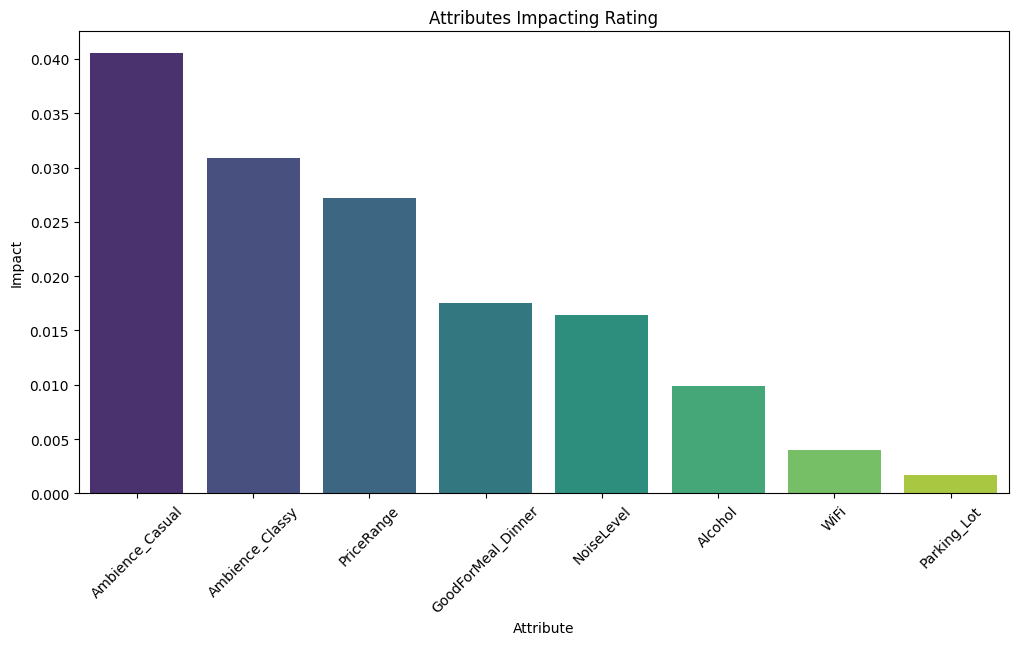

In [18]:
from pyspark.sql.functions import avg, pow, col, count, sum as Fsum

overall_mean = restaurants_df.select(avg('stars').alias('mean_rating')).collect()[0]['mean_rating']

sst_row = restaurants_df.withColumn('squared_diff', pow(col('stars') - overall_mean, 2)) \
                        .agg(Fsum('squared_diff').alias('sst')).collect()

if len(sst_row) > 0 and sst_row[0]['sst'] is not None:
    sst = sst_row[0]['sst']
else:
    print("SST calculation failed.")
    sst = None

attributes = [
    'Alcohol', 'WiFi', 'NoiseLevel', 'GoodForKids', 'HasTV', 'OutdoorSeating',
    'RestaurantsGoodForGroups', 'PriceRange', 'Ambience_Casual', 'Ambience_Classy',
    'Parking_Lot', 'GoodForMeal_Dinner'
]

r_squared_list = []

for attr in attributes:
    df = restaurants_df.filter(col(attr).isNotNull())
    
    if df.count() > 0:
        group_stats = df.groupBy(attr).agg(
            count('*').alias('n_i'),
            avg('stars').alias('mean_i')
        )

        group_stats = group_stats.withColumn('mean_diff_sq', pow(col('mean_i') - overall_mean, 2))

        group_stats = group_stats.withColumn('ssb_i', col('n_i') * col('mean_diff_sq'))

        ssb_row = group_stats.agg(Fsum('ssb_i').alias('ssb')).collect()

        if len(ssb_row) > 0 and ssb_row[0]['ssb'] is not None:
            ssb = ssb_row[0]['ssb']
            if sst and sst != 0:
                r_squared = ssb / sst
            else:
                r_squared = None
        else:
            r_squared = None
    else:
        r_squared = None

    if r_squared is not None:
        r_squared_list.append({'Attribute': attr, 'R_squared': r_squared})

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

r_squared_df = pd.DataFrame(r_squared_list)

r_squared_df = r_squared_df.sort_values('R_squared', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    data=r_squared_df,
    x='Attribute',
    y='R_squared',
    palette='viridis'
)
plt.xlabel('Attribute')
plt.ylabel('Impact')
plt.title('Attributes Impacting Rating')
plt.xticks(rotation=45)
plt.show()

In [19]:
# Query 4 - Complex: Correlation Between Review Sentiment and Restaurant Ratings

reviews_df = spark.read.json("file:///home/dps/Documents/yelp_dataset/yelp_academic_dataset_review.json")

restaurant_reviews_df = reviews_df.join(restaurants_df.select('business_id'), on='business_id', how='inner')

from pyspark.sql.functions import udf
from textblob import TextBlob

def analyze_sentiment(text):
    try:
        return TextBlob(text).sentiment.polarity
    except:
        return 0.0

sentiment_udf = udf(analyze_sentiment, FloatType())

restaurant_reviews_df = restaurant_reviews_df.withColumn('sentiment_score', sentiment_udf(col('text')))

restaurant_reviews_df.createOrReplaceTempView("restaurant_reviews")


sentiment_rating_df = spark.sql("""
SELECT
    r.business_id,
    AVG(r.sentiment_score) AS avg_sentiment,
    b.stars AS avg_rating,
    COUNT(r.review_id) AS total_reviews
FROM
    restaurant_reviews r
JOIN
    restaurants b ON r.business_id = b.business_id
GROUP BY
    r.business_id, b.stars
HAVING
    total_reviews >= 50
""")
sentiment_rating_df.show()

+--------------------+--------------------+----------+-------------+
|         business_id|       avg_sentiment|avg_rating|total_reviews|
+--------------------+--------------------+----------+-------------+
|rdtMeOwRcXw4mJVxi...| 0.28158836532747955|       4.0|           64|
|5ewePyN_mEE_79OmY...|-0.09853789607683817|       1.5|           90|
|0z-pNv_92L_-LiYV_...| 0.25298043504427437|       3.5|           93|
|-y5vYOsyL4bSFxeOt...|   0.271734421086637|       4.0|          274|
|UCMSWPqzXjd7QHq7v...| 0.32995050379953184|       4.5|         2230|
|LDkD5R5N7CG9yCD0Y...| 0.22509771946679905|       4.0|           71|
|h0Zxv2SpGNzZGZuJA...|  0.3016246705980545|       4.0|           96|
|avcOkMsnFse9D-DpI...| 0.10764805886168846|       2.5|          103|
|Nz0AJVskEAlMVgF2H...| 0.14751899061867824|       3.0|           65|
|jmwasbZfgj3honf79...|  0.3577528224844513|       4.5|          821|
|D7z_V6E8cxXghSRcH...|  0.2452565032315064|       4.0|           94|
|9C2rpb56aQvW0ViZH...|  0.17415902

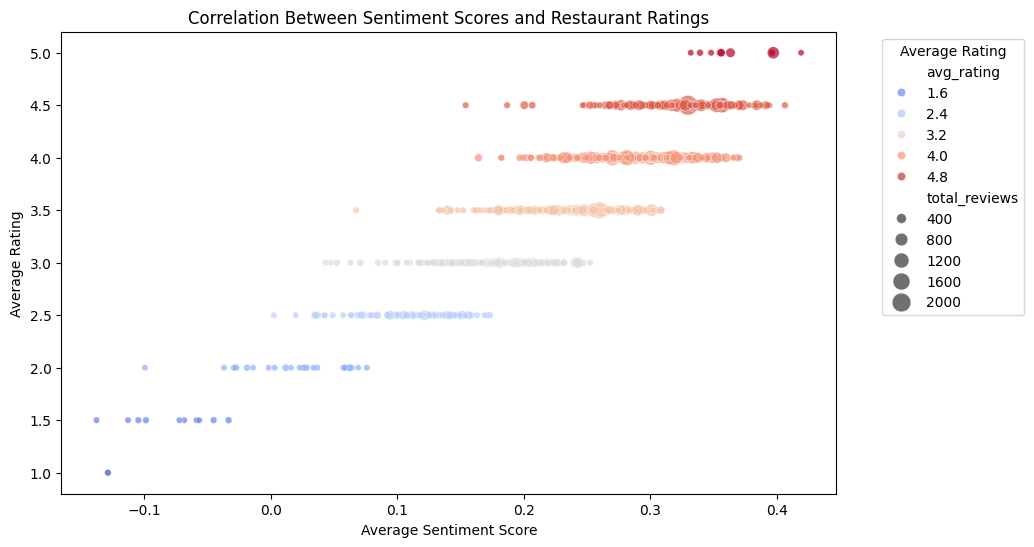

In [20]:
sentiment_rating_pd = sentiment_rating_df.toPandas()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=sentiment_rating_pd,
    x='avg_sentiment',
    y='avg_rating',
    size='total_reviews',
    hue='avg_rating',
    palette='coolwarm',
    sizes=(20, 200),
    alpha=0.7
)
plt.xlabel('Average Sentiment Score')
plt.ylabel('Average Rating')
plt.title('Correlation Between Sentiment Scores and Restaurant Ratings')
plt.legend(title='Average Rating', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

In [21]:
# Query 5 - Complex: Popular Meal Times and Their Effect on Ratings

meal_times = ['Breakfast', 'Brunch', 'Lunch', 'Dinner', 'Dessert', 'Latenight']

restaurants_df_meals = restaurants_df

for meal in meal_times:
    col_name = f"GoodForMeal_{meal}"
    restaurants_df_meals = restaurants_df_meals.withColumn(col_name, when(col(col_name) == True, meal).otherwise(None))

restaurants_df_meals = restaurants_df_meals.withColumn('MealTimes', array([col(f"GoodForMeal_{meal}") for meal in meal_times]))

restaurants_df_meals = restaurants_df_meals.withColumn('MealTime', explode('MealTimes'))

restaurants_df_meals = restaurants_df_meals.filter(col('MealTime').isNotNull())

restaurants_df_meals.createOrReplaceTempView("restaurants_meals")

meal_time_df = spark.sql("""
SELECT
    MealTime,
    ROUND(AVG(stars), 2) AS avg_rating,
    COUNT(*) AS total_restaurants
FROM
    restaurants_meals
GROUP BY
    MealTime
ORDER BY
    avg_rating DESC
""")
meal_time_df.show()

+---------+----------+-----------------+
| MealTime|avg_rating|total_restaurants|
+---------+----------+-----------------+
|   Brunch|      3.69|              175|
|   Dinner|      3.65|              718|
|    Lunch|      3.61|              858|
|Breakfast|      3.55|              233|
|  Dessert|      3.49|               96|
|Latenight|      3.37|               64|
+---------+----------+-----------------+



/tmp/ipykernel_75447/1784779590.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


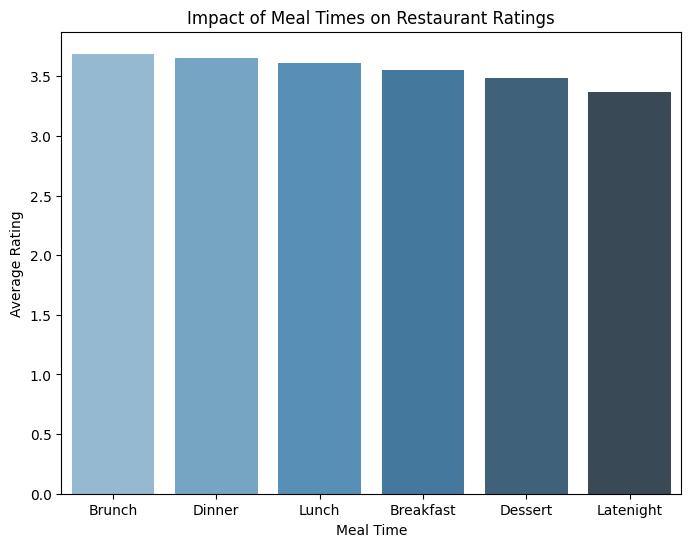

In [22]:
meal_time_pd = meal_time_df.toPandas()

plt.figure(figsize=(8,6))
sns.barplot(
    data=meal_time_pd,
    x='MealTime',
    y='avg_rating',
    palette='Blues_d'
)
plt.xlabel('Meal Time')
plt.ylabel('Average Rating')
plt.title('Impact of Meal Times on Restaurant Ratings')
plt.show()